In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# **Relationship Between Features**

The Energy Efficiency dataset contains eight independent variables and two target variables.

## **Independent Variables**

- X1 : Relative Compactness
- X2 : Surface Area
- X3 : Wall Area
- X4 : Roof Area
- X5 : Overall Height
- X6 : Orientation
- X7 : Glazing Area
- X8 : Glazing Area Distribution

## **Target Variables**

- Y1 : Heating Load
- Y2 : Cooling Load

## **Relationship Between Features**

- Relative Compactness has an inverse relationship with Surface Area.
- Surface Area influences the total heat transfer.
- Wall Area and Roof Area affect insulation and energy consumption.
- Overall Height changes the heating and cooling requirements.
- Orientation determines sunlight exposure.
- Glazing Area affects heat gain through windows.
- Heating Load (Y1) and Cooling Load (Y2) are closely related because both depend on the building's physical characteristics.

# **Dataset Header**

In [3]:
df = pd.read_csv("energy.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


# **Dataset Understanding**
This includes:
- Number of rows and columns
- Data types
- Missing values
- Statistical summary
- Structure of the dataset

In [5]:
print("Shape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

print("\nMissing Values")
display(df.isnull().sum())

Shape of Dataset
(768, 10)

Column Names
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB

Statistical Summary


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000



Missing Values


,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
Y1,0
Y2,0


# **Vizualizations**

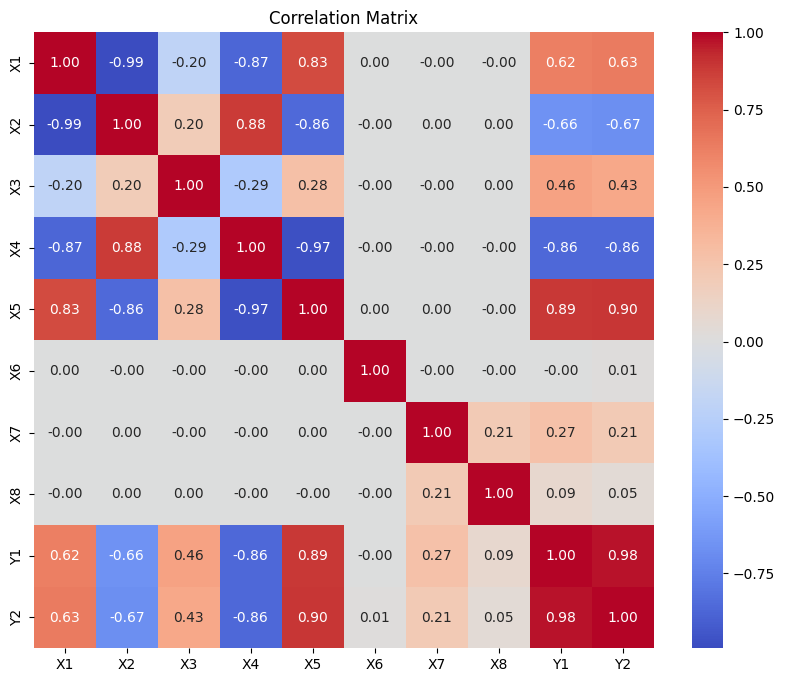

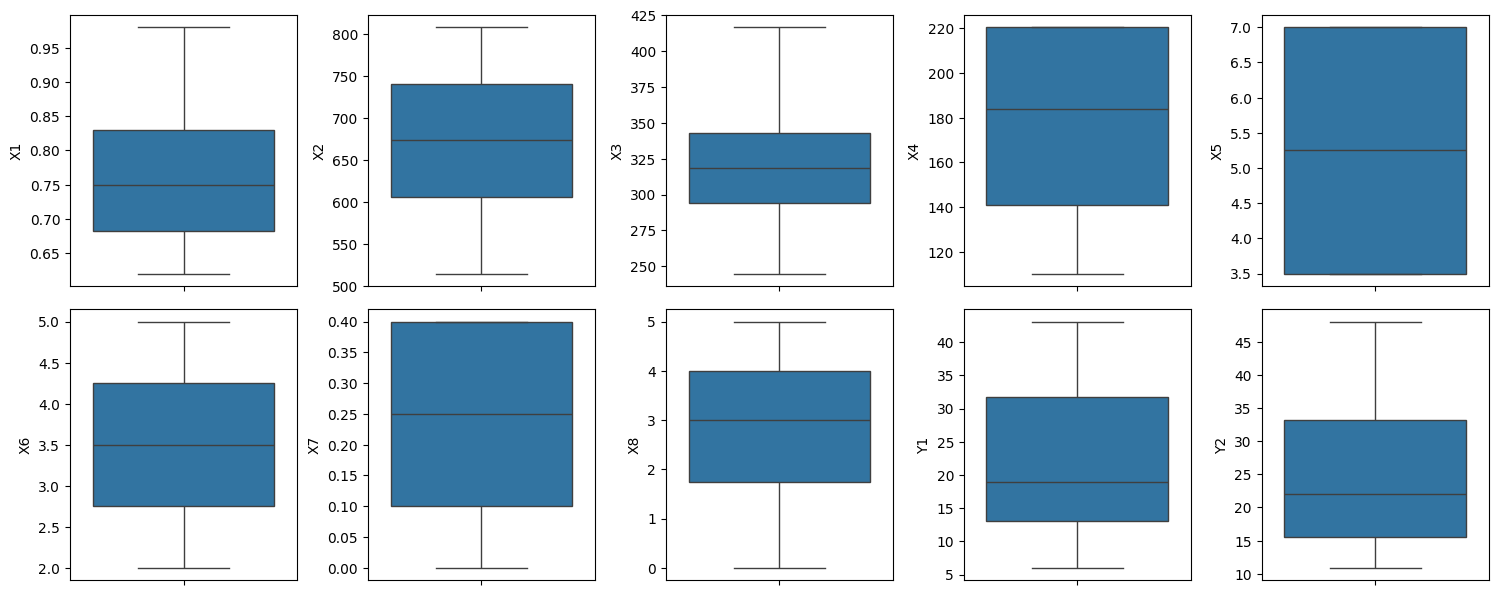

In [8]:
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#box plot
plt.figure(figsize=(15,6))
for i, col in enumerate(df.columns):
    plt.subplot(2,5,i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

# **Test train split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape : (614, 8)
Testing Data Shape : (154, 8)


# **Linear regression**

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
comparison.head(10)

,Actual,Predicted
668,16.47,18.862960
324,13.17,14.049380
624,32.82,31.315603
690,41.32,35.900510
473,16.69,15.335197
204,23.80,28.618749
97,24.31,25.029103
336,28.67,28.083021
568,19.52,17.755807
148,28.07,27.599255


# **Insight**

- The Linear Regression model successfully learned the relationship between the building characteristics (X1–X8) and the Heating Load (Y1).
- Since the dataset is clean and numerical, Linear Regression is an appropriate algorithm for this regression problem.